In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Refrence : https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/gene-expression-level

In [2]:
df=pd.read_csv('gene_expression.csv')
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [4]:
X=df.drop('Cancer Present' , axis=1)
y=df['Cancer Present']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scale=StandardScaler()
knn=KNeighborsClassifier()

In [17]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [5]:
operations=[('scale' , scale) , ('knn' , knn)]

In [6]:
pipe=Pipeline(operations)

# Full Cross Validation Grid Search for K Value

In [7]:
k_values=list(range(1,20))
param_grid={'knn__n_neighbors' : k_values}
knn_cv_model=GridSearchCV(pipe , param_grid , cv=10 , scoring='roc_auc')

In [8]:
knn_cv_model.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [9]:
knn_cv_model.best_estimator_.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=19))],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=19),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 19,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [10]:
pd.DataFrame(knn_cv_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004328,0.000520,0.003756,0.000629,1,{'knn__n_neighbors': 1},0.900599,0.899691,0.905453,0.852055,0.909582,0.890527,0.914255,0.890164,0.929181,0.894837,0.898634,0.019157,19
1,0.003106,0.000962,0.002750,0.000939,2,{'knn__n_neighbors': 2},0.956492,0.943834,0.955812,0.909037,0.933627,0.936712,0.937256,0.953770,0.964704,0.924961,0.941621,0.015982,18
2,0.003309,0.000922,0.003489,0.001109,3,{'knn__n_neighbors': 3},0.963479,0.965883,0.975229,0.906905,0.958670,0.955494,0.954587,0.965203,0.981490,0.948643,0.957558,0.019254,17
3,0.002660,0.000747,0.002415,0.000358,4,{'knn__n_neighbors': 4},0.964295,0.965021,0.979221,0.910035,0.970647,0.971282,0.958488,0.970057,0.987887,0.955948,0.963288,0.019849,16
4,0.002509,0.000600,0.002711,0.000901,5,{'knn__n_neighbors': 5},0.968605,0.964023,0.980401,0.926504,0.972598,0.972144,0.972053,0.973460,0.989248,0.964477,0.968351,0.015618,15
5,0.002714,0.000980,0.003048,0.001300,6,{'knn__n_neighbors': 6},0.968333,0.964295,0.979040,0.930632,0.972008,0.973550,0.975184,0.973641,0.990064,0.969195,0.969594,0.014578,14
6,0.002782,0.001032,0.002758,0.000747,7,{'knn__n_neighbors': 7},0.968152,0.966201,0.978722,0.933899,0.977225,0.972870,0.976817,0.973732,0.989838,0.967471,0.970493,0.013840,13
7,0.004349,0.000575,0.004180,0.000140,8,{'knn__n_neighbors': 8},0.968197,0.968787,0.982261,0.931857,0.978133,0.972915,0.976681,0.973641,0.991017,0.965883,0.970937,0.014807,12
8,0.004099,0.000076,0.004194,0.000064,9,{'knn__n_neighbors': 9},0.968878,0.969195,0.982987,0.934443,0.979993,0.972235,0.976227,0.973324,0.991471,0.963932,0.971268,0.014392,11
9,0.002914,0.000948,0.003348,0.000920,10,{'knn__n_neighbors': 10},0.972008,0.968968,0.983804,0.933627,0.979675,0.975864,0.976681,0.972507,0.991652,0.967970,0.972276,0.014556,10


In [11]:
knn_cv_model.cv_results_['mean_test_score']

array([0.89863443, 0.94162054, 0.9575583 , 0.96328827, 0.96835133,
       0.96959441, 0.9704927 , 0.9709373 , 0.97126849, 0.97227566,
       0.97335088, 0.97415389, 0.9754378 , 0.97564196, 0.97659015,
       0.9767081 , 0.97750658, 0.97801924, 0.97848653])

# final model

In [12]:
scale=StandardScaler()
knn19=KNeighborsClassifier(n_neighbors=19)
operation=[('scale' , scale) , ('knn19' , knn19)]
pipe19=Pipeline(operation)
pipe19.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('knn19', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",3

In [14]:
y_pred=pipe19.predict(X_test)

In [15]:
from sklearn.metrics import classification_report , ConfusionMatrixDisplay , RocCurveDisplay , PrecisionRecallDisplay

In [16]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       470
           1       0.95      0.94      0.95       430

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



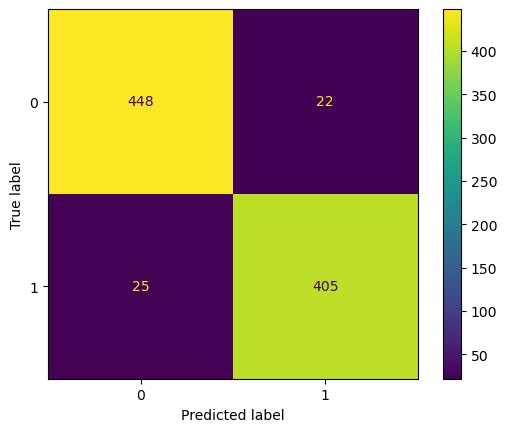

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred)

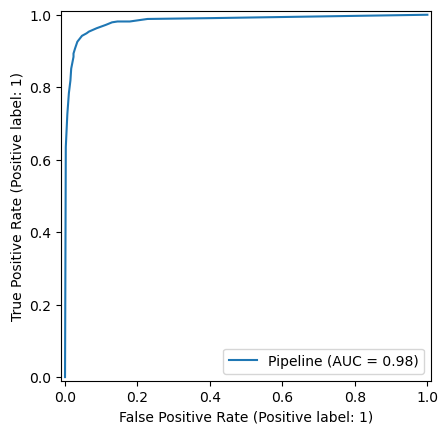

In [18]:
RocCurveDisplay.from_estimator(pipe19 , X_test , y_test)

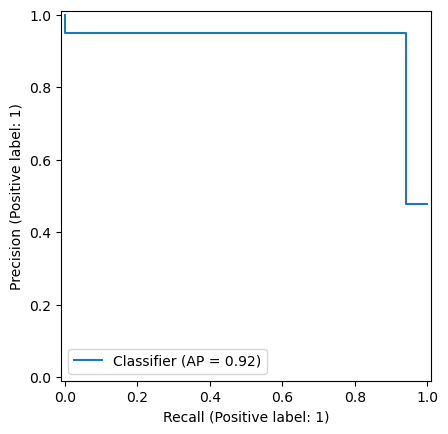

In [19]:
PrecisionRecallDisplay.from_predictions(y_test , y_pred)

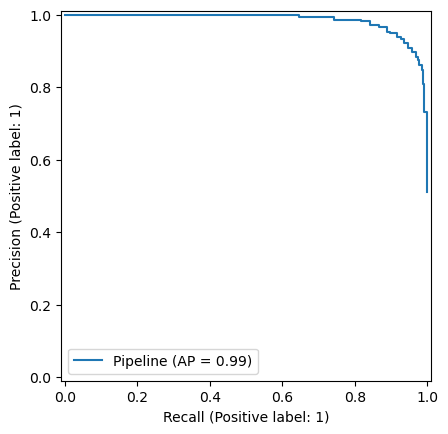

In [20]:
PrecisionRecallDisplay.from_estimator(pipe19 , X_train , y_train)

In [130]:
sampel=X_test.iloc[30]
sampel

Gene One    7.0
Gene Two    3.1
Name: 1005, dtype: float64

In [132]:
pipe17.predict(sampel.values.reshape(1, -1))

C:\Users\Ziba\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)